In [8]:
import sys
import os
import os
import phydrus as ps
import numpy as np
%matplotlib inline
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)

from model_build import InfiltrationModel

In [ ]:
soil_props = {"a": [0.075],"tr": [0.065],"ths": [0.41],"ks": [106.1 / 1440],"n": [1.89],'m': [1 - 1/1.89],'L':[0.5]}
pond_max= 0.0
discretize = {"layers": [100], "dz": [1]}
bound_bot = 'free drainage'
bound_top = 'constant head'
flux_top,flux_bot = np.array([0]*10),np.array([0]*10)
transp = np.zeros(flux_bot.shape[0])
temp_time  = 144.0 # saving the moisture each same time 
sim_time = temp_time * flux_top.shape[0] * 10
head_bot,head_top = np.zeros(flux_top.shape),np.ones(flux_top.shape)
trans = np.array([0.0] * (flux_top.shape[0]),dtype=np.float64) # if root wateruptake is active transpiration needs to be given 
hyd_model = 'VGM'


[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.] [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [42]:
# Folder for Hydrus files to be stored
ws = "example_1"
exe = os.path.join('/Users/onursahin/Flux1Dpy/hydrus_source/source_code/source/hydrus')  
# Description
desc = "Infiltration of Water into a Single-Layered Soil Profile"
# Create model
ml = ps.Model(exe_name=exe, ws_name=ws, name="model", description=desc, mass_units="mmol",
              time_unit="days", length_unit="cm")
ml.basic_info["lFlux"] = True
ml.basic_info["lShort"] = False

ml.add_time_info(tmax=1, print_times=True, nsteps=10, dt=0.001)
ml.add_waterflow(top_bc=0, bot_bc=4)

m = ml.get_empty_material_df(n=1)
m.loc[[1]] = [[0.078, 0.43, 0.036, 1.56, 24.96, 0.5]]
ml.add_material(m)
elements = 100  # Disctretize soil column into n elements
depth = -100  # Depth of the soil column
ihead = -100  # Determine initial Pressure Head
# Create Profile
profile = ps.create_profile(bot=depth, dx=abs(depth / elements), h=ihead)
profile.iloc[0, 1] = 1  # Define initial Pressure Head at the surface
ml.add_profile(profile)  # Add the profile
# Add observation nodes at depth
ml.add_obs_nodes([-20, -40, -60, -80, -100])
ml.write_input()
ml.simulate()



INFO: Successfully wrote example_1/SELECTOR.IN
INFO: Successfully wrote example_1/PROFILE.DAT
INFO: Hydrus-1D Simulation Successful.


CompletedProcess(args=['/Users/onursahin/Flux1Dpy/hydrus_source/source_code/source/hydrus', 'example_1', '-1'], returncode=0)

/Users/onursahin/miniforge3/envs/work_env/lib/python3.14/site-packages/phydrus/read.py:259: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df1 = read_csv(path, skiprows=start, index_col=0, nrows=end - start - 1,


<Axes: xlabel='Time [days]', ylabel='h'>

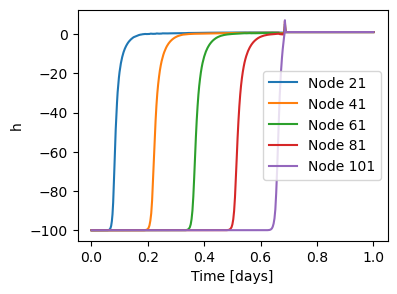

In [43]:
ml.plots.obs_points()

/Users/onursahin/miniforge3/envs/work_env/lib/python3.14/site-packages/phydrus/read.py:320: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data[time] = read_csv(file, skiprows=s,
/Users/onursahin/miniforge3/envs/work_env/lib/python3.14/site-packages/phydrus/read.py:320: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data[time] = read_csv(file, skiprows=s,
/Users/onursahin/miniforge3/envs/work_env/lib/python3.14/site-packages/phydrus/read.py:320: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data[time] = read_csv(file, skiprows=s,
/Users/onursahin/miniforge3/envs/work_env/lib/python3.14/site-packages/phydrus/read.py:320: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and w

<Axes: xlabel='h [cm]', ylabel='Depth [cm]'>

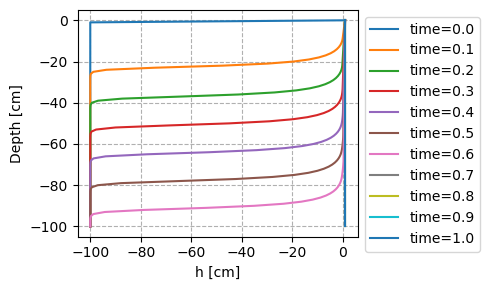

In [44]:
ml.plots.profile_information()